# Cuaderno 2.1 Aprendizaje Supervisado

El propósito de este cuaderno es explorar el modelo de regresión lineal discutido en el Capítulo 2 del libro.

Trabaje con las celdas a continuación, ejecutando cada celda a su vez. En varios lugares verá las palabras "TAREA PENDIENTE". Siga las instrucciones en estos lugares y escriba código para completar las funciones. También hay preguntas intercaladas en el texto.

Contácteme en udlbookmail@gmail.com si encuentra algún error o tiene alguna sugerencia.

In [1]:
# Librería matemática
import numpy as np
# Librería de trazado
import matplotlib.pyplot as plt

In [2]:
# Crear algunos datos de entrada / salida
x = np.array([0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90])
y = np.array([0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6 ])

print(x)
print(y)

[0.03 0.19 0.34 0.46 0.78 0.81 1.08 1.18 1.39 1.6  1.65 1.9 ]
[0.67 0.85 1.05 1.   1.4  1.5  1.3  1.54 1.55 1.68 1.73 1.6 ]


In [3]:
# Definir el modelo de regresión lineal 1D
def f(x, phi0, phi1):
  # El modelo de regresión lineal (ecuación 2.4) ya está implementado,
  y = phi0 + phi1*x

  return y

In [4]:
# Función para ayudar a graficar los datos
def plot(x, y, phi0, phi1):
    fig,ax = plt.subplots()
    ax.scatter(x,y)
    plt.xlim([0,2.0])
    plt.ylim([0,2.0])
    ax.set_xlabel('Entrada, $x$')
    ax.set_ylabel('Salida, $y$')
    # Dibujar línea
    x_line = np.arange(0,2,0.01)
    y_line = f(x_line, phi0, phi1)
    plt.plot(x_line, y_line,'b-',lw=2)

    plt.show()

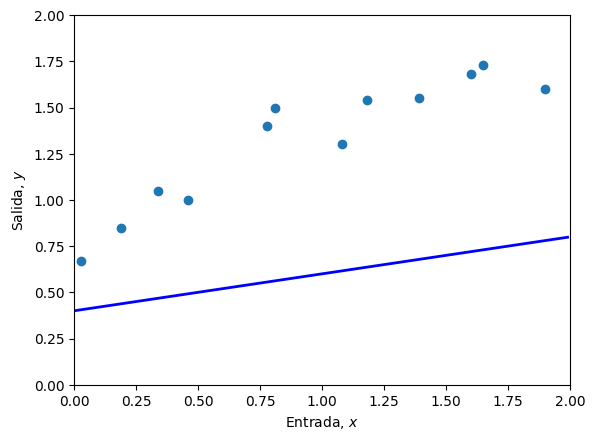

In [5]:
# Establecer la intersección y la pendiente como en la figura 2.2b
phi0 = 0.4 ; phi1 = 0.2
# Graficar los datos y el modelo
plot(x,y,phi0,phi1)

In [6]:
# Función para calcular la pérdida
def compute_loss(x,y,phi0,phi1):

  # TAREA PENDIENTE Reemplace esta línea con el cálculo de la pérdida (ecuación 2.5)
    loss = 0
    for i in range(len(x)):
        loss += (phi0 + phi1*x[i] - y[i])**2

    return loss

In [7]:
# Calcular la pérdida para nuestro modelo actual
loss = compute_loss(x,y,phi0,phi1)
print(f'Su pérdida = {loss:3.2f}, Valor real =7.07')

Su pérdida = 7.07, Valor real =7.07


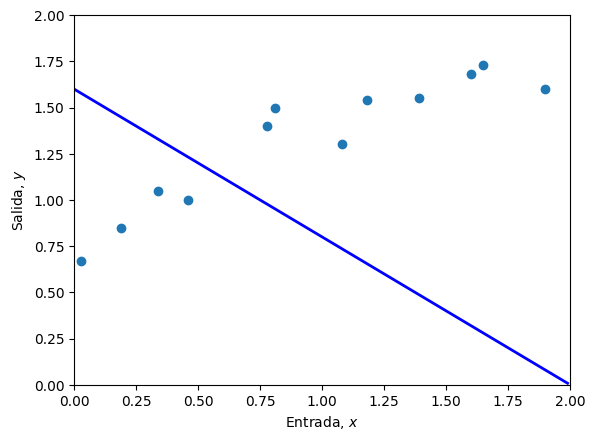

Su pérdida = 10.28, Valor real =10.28


In [8]:
# Establecer la intersección y la pendiente como en la figura 2.2c
phi0 = 1.60 ; phi1 =-0.8
# Graficar los datos y el modelo
plot(x,y,phi0,phi1)
loss = compute_loss(x,y,phi0,phi1)
print(f'Su pérdida = {loss:3.2f}, Valor real =10.28')

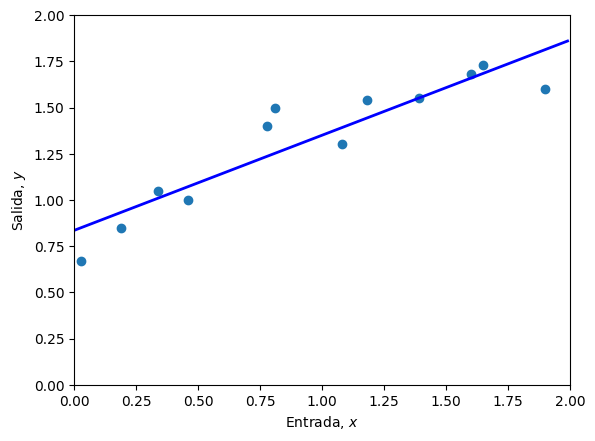

Su pérdida = 0.20


In [9]:
# TAREA PENDIENTE -- Cambiar manualmente los parámetros para ajustar el modelo
# Primero, fije phi1 e intente cambiar phi0 hasta que no pueda reducir más la pérdida.
# Luego, fije phi0 e intente cambiar phi1 hasta que no pueda reducir más la pérdida.
# Repita este proceso hasta que encuentre un conjunto de parámetros que ajusten el modelo como en la figura 2.2d
# Puede hacerlo a mano, o si quiere ser más sofisticado, escriba código para descender automáticamente de esta manera.
# Comience con estos valores:
phi0 = 0.835 ; phi1 =0.515

plot(x,y,phi0,phi1)
print(f'Su pérdida = {compute_loss(x,y,phi0,phi1):3.2f}')

# Visualizando la función de pérdida

El proceso anterior es equivalente a descender coordenada a coordenada en la función de pérdida.<br>

Ahora vamos a graficar esa función.

In [10]:
# Crear una cuadrícula 2D de posibles valores de phi0 y phi1
phi0_mesh, phi1_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.02))

# Crear un array 2D para las pérdidas
all_losses = np.zeros_like(phi1_mesh)
# Recorrer cada combinación 2D de phi0, phi1 y calcular la pérdida
for indices,temp in np.ndenumerate(phi1_mesh):
    all_losses[indices] = compute_loss(x,y, phi0_mesh[indices], phi1_mesh[indices])

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1530/832381856.py:10: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Intersección, $\phi_0$')
/tmp/ipykernel_1530/832381856.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('Pendiente, $\phi_1$')


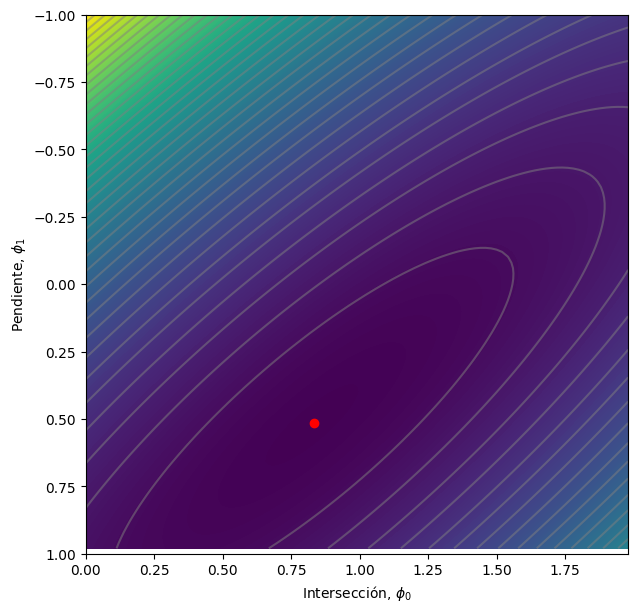

In [11]:
# Graficar la función de pérdida como un mapa de calor
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel('Intersección, $\phi_0$')
ax.set_ylabel('Pendiente, $\phi_1$')

# Graficar la posición de su línea de mejor ajuste en la función de pérdida
# Debería estar cerca del mínimo
ax.plot(phi0,phi1,'ro')
plt.show()